# Part 5: who runs next, and what you do not run

`admit -> place -> your queue -> engine waiting / running / preempt` on **one H100 PCIe split into two MIG instances**
(two SGLang workers, `Qwen/Qwen3.5-9B` bf16, 6 sequences of 64K per worker) behind LiteLLM with our control plane.

Every answer below is read from data of the runs (`metrics/runs/<experiment>/<variant>/`: `records.jsonl` is the raw
per-call data, `prometheus.json` the scrape taken at the end of the run, `timeline.csv` per minute) or from the
manifests. The load comes from `script/loadgen.py`: closed-loop agent sessions (shared system+tools prefix, context that
grows per step, tool pauses). **N** is the number of sessions working at once, **K = 2** the requests allowed to wait
beyond the 12 that run. Run it from the repository root: `python3 notebook/run_notebook.py` (a Markdown copy, readable without a server, is `notebook/part5_queue.md`).

In [1]:
import json, glob, os, re, urllib.request
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd()
while not (ROOT / "metrics").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
RUNS = ROOT / "metrics" / "runs"
pd.set_option("display.width", 160); pd.set_option("display.max_columns", 30)

def load(exp, variant):
    d = RUNS / exp / variant
    return {"summary": json.load(open(d / "summary.json")),
            "prom": json.load(open(d / "prometheus.json")),
            "records": pd.read_json(d / "records.jsonl", lines=True),
            "timeline": pd.read_csv(d / "timeline.csv")}

def series(prom, key, label):
    # one value per label combination -> {label value: value}
    return {s["labels"].get(label, "-"): s["value"] for s in prom.get(key, [])}

def live(query):
    # scrape the live Prometheus when it is reachable (tunnel to :9090); otherwise None
    url = os.environ.get("PROM_URL", "http://localhost:9090") + "/api/v1/query?query=" + urllib.parse.quote(query)
    try:
        with urllib.request.urlopen(url, timeout=3) as r:
            return json.load(r)["data"]["result"]
    except Exception:
        return None
import urllib.parse
print("repo root:", ROOT.name)
print("runs:", sorted(p.name for p in RUNS.iterdir()))

repo root: coding-agent-inference-infra
runs: ['eq-k-n28', 'eq-k2-n20', 'eq-k2-n24', 'eq-ref-n20', 'eq-ref-n28', 'er-n20', 'er-n24', 'ev-n16', 'fin-batch', 'fin-knee', 'fin-regimeB', 'fin-rep-affload', 'fin-rep-lb', 'fin-soak', 'fin2-agents', 'fin2-batch', 'fin2-n20', 'fin2-regimeB', 'fin3-batch', 'fin4-batch', 'smoke']


## 1. Who sits in our queue, and who in the engine's waiting queue?

We do not queue at the gateway. Measured first with a gateway queue of 64 (`eq-ref-*`) and then with a counter
(`eq-k*`): a longer queue only keeps the engine in its slow regime (decision 34). The gateway only **caps the requests in flight at
12 + K = 14** (LiteLLM's own admission middleware, `cluster/litellm/config.yaml`); the next request gets an immediate 503. The K = 2
admitted requests beyond the 12 running ones wait in **SGLang's priority queue** (`--enable-priority-scheduling`). The runs
below (`fin-*`) are the final configuration under 360 s runs.

In [2]:
exp, var = "fin-knee", "N24"
r = load(exp, var)
prom = r["prom"]
rows = {
  "requests in flight in the gateway, max (cap 14)": series(prom, "gateway_in_flight_max", "x"),
  "engine waiting queue, max, per worker": series(prom, "engine_queue_max", "worker"),
  "engine running, max, per worker (limit 6)": series(prom, "engine_running_max", "worker"),
  "engine retracted (preempted), max, per worker": series(prom, "retracted_max", "worker"),
}
for k, v in rows.items():
    print(f"{k:55s}", v)

requests in flight in the gateway, max (cap 14)         {'-': 14.0}
engine waiting queue, max, per worker                   {'0': 3.0, '1': 2.0}
engine running, max, per worker (limit 6)               {'0': 6.0, '1': 6.0}
engine retracted (preempted), max, per worker           {'0': 0.0, '1': 0.0}


Reading: at N = 24 (heavy overload) the cap was reached (14 in flight) and the engine queue stayed at 2-3 on a worker. The K = 2
allowance is fleet-wide, not per worker: when one worker has fewer than 6 running the other can hold both waiting requests (and a
gauge that is stale by seconds can show a little more), which is why placement matters for queueing (section 2). Every refused
request was refused at the door, none waited at the gateway. The soak shows the same over time (`plots/final_soak.png`, below).

## 2. Waiting / running / preempted, and `orch_replica_queue_depth`: which pod, under which mix?

In [3]:
sheds = prom["shed_by_reason"]
print("sheds by reason (requests during the measured window):")
print(pd.DataFrame([{"reason": s["labels"]["reason"], "class": s["labels"]["priority_class"], "n": s["value"]} for s in sheds if s["value"]]))
# per worker snapshot of the three states, across the four routing policies of the N = 24 experiment
out = []
for v in ["lb", "shuffle", "aff", "affload"]:
    p = load("er-n24", v)["prom"]
    for w in ("0", "1"):
        out.append({"policy": v, "worker": w,
                    "waiting max": series(p, "engine_queue_max", "worker").get(w),
                    "running max": series(p, "engine_running_max", "worker").get(w),
                    "retracted max": series(p, "retracted_max", "worker").get(w)})
pd.DataFrame(out).pivot(index="policy", columns="worker")

sheds by reason (requests during the measured window):
            reason        class           n
0  decode_capacity  interactive  616.666667
1         ttft_cut  interactive    1.007433


waiting max      running max      retracted max     
worker            0    1           0    1             0    1
policy                                                      
aff             7.0  1.0         6.0  4.0           0.0  0.0
affload         3.0  2.0         6.0  6.0           0.0  0.0
lb              4.0  3.0         6.0  6.0           0.0  0.0
shuffle         4.0  3.0         6.0  6.0           0.0  0.0

Names: the waiting / running / preempted states are `sglang:num_queue_reqs`, `sglang:num_running_reqs` and `sglang:num_retracted_reqs` (per worker);
our equivalent of `orch_replica_queue_depth` is `litellm_orch_replica_queue_depth{replica}` (the control plane's last scrape of the same
waiting-queue gauge; it is what the admission checks read, and section 12 prints it live). The shed table comes from the `fin-*` runs, made before the
admission was simplified: `decode_capacity` there is the refusal of the old in-flight counter (today's `queue_full` of the cap) and `ttft_cut` is the
first-token cut that was later removed.

Reading: the mix is 100 % interactive sessions of the `paper` profile at N = 24. `aff` (static hash) piled 7 requests in
worker 0's queue and 1 in worker 1's: that is the pod-level answer to *which pod*, and the reason the placement policy
matters for queueing. With `affload` the queues are 3/2. **Nothing was preempted** in any run (`retracted max` 0): KV
never filled (see 6).

## 3. A 32K retrieval and a short agent decode are both ready: who goes first?

Two levels, as in the design:
1. **Gateway (us):** both take a place if one is free; if none is free, the interactive one still has the reserved
   places (batch is admitted only while fewer than 10 of the 14 are in use, so the last 4 are for interactive calls) and both are refused at once otherwise. Priority is forwarded to the engine
   in `extra_body.priority`.
2. **Engine (SGLang):** once both are inside, the engine decides: priority scheduling orders its waiting queue (lower
   number first) and **chunked prefill** cuts the 32K prefill into chunks of `--chunked-prefill-size` so decode steps of
   the short request interleave between chunks. We do not interleave ourselves.

In [4]:
import yaml
cfg = yaml.safe_load(open(ROOT / "cluster/sglang/config.yaml"))["data"]
w0 = open(ROOT / "cluster/sglang/worker-0.yaml").read()
flags = re.findall(r"^\s+- (--[a-z0-9-]+)\s*(?:#.*)?$", w0, re.M)
print("ConfigMap sglang-config:")
for k in ("MODEL_NAME","KV_CACHE_DTYPE","MAX_MODEL_LEN","MAX_NUM_SEQS","MAX_MEM_FRAC","MAMBA_FULL_MEMORY_RATIO","CHUNKED_PREFILL_SIZE","RADIX_EVICTION_POLICY","HICACHE_WRITE_POLICY"):
    print(f"  {k:26s}{cfg.get(k)}")
print("engine flags in worker-0.yaml:", flags)

ConfigMap sglang-config:
  MODEL_NAME                Qwen/Qwen3.5-9B
  KV_CACHE_DTYPE            auto
  MAX_MODEL_LEN             65536
  MAX_NUM_SEQS              6
  MAX_MEM_FRAC              0.85
  MAMBA_FULL_MEMORY_RATIO   0.17
  CHUNKED_PREFILL_SIZE      4096
  RADIX_EVICTION_POLICY     lru
  HICACHE_WRITE_POLICY      write_through
engine flags in worker-0.yaml: ['--model-path', '--host', '--port', '--context-length', '--max-running-requests', '--max-queued-requests', '--chunked-prefill-size', '--reasoning-parser', '--tool-call-parser', '--enable-metrics', '--cuda-graph-backend-prefill', '--kv-cache-dtype', '--mamba-full-memory-ratio', '--mem-fraction-static', '--enable-priority-scheduling', '--schedule-low-priority-values-first', '--default-priority-value', '--retraction-policy', '--enable-hierarchical-cache', '--enable-cache-report', '--hicache-size', '--hicache-write-policy', '--hicache-storage-backend', '--hicache-storage-backend-extra-config', '--radix-eviction-policy']


**Engine flags used, and why** (`cluster/sglang/worker-0.yaml`, `sglang-config`). Continuous batching is always on in SGLang (there is no flag).
SGLang's names differ from vLLM's:

| Flag | Value | vLLM equivalent | Why |
| --- | --- | --- | --- |
| `--max-running-requests` | 6 | `max-num-seqs` | the KV pool of a worker holds 435,199 tokens = 6.6 sequences of 64K; 6 cannot overcommit it (88 %). Raising it only triggers retraction and re-prefill |
| `--chunked-prefill-size` | 4096 | `max-num-batched-tokens` (prefill part) | a long prefill is cut into chunks of 4096 tokens so decode steps of other sequences run between them. The value was kept from the default; the alternatives (1024-8192) were not run (decision [36](../ARCHITECTURE.md#decision-36)) |
| `--enable-priority-scheduling`, `--schedule-low-priority-values-first`, `--retraction-policy priority` | on | scheduling policy | the engine orders its own waiting queue by priority and retracts the least urgent request first |
| `--mem-fraction-static` | 0.85 | `gpu-memory-utilization` | share of the 39.5 GiB MIG instance for weights, KV and states |
| `--mamba-full-memory-ratio` | 0.17 | (hybrid model only) | share of the pool kept for recurrent states; the default 0.9 left 4 sequences of 64K |
| `--cuda-graph-backend-prefill` | disabled | - | prefill graphs cost 5.4 GB and 209 s per worker and add little with chunked prefill |

Evidence for the interleaving cost: decode per sequence fell from **48.8 tok/s idle to 26.6 (N = 20) and 15.4 (N = 28)**
(`notes/findings.md`, "Engine configuration review"), i.e. long prefills do slow every decode on the same worker;
chunked prefill (4096) bounds how long. That is why the capacity limiter turned out to be the per-call cost under load,
not the slot count.

## 4. PagedAttention vs radix cache: which one saved memory, which saved compute?

Paging removes fragmentation (a sequence uses only the blocks it needs): it is always on. The **radix cache** saves
*compute*, and memory only for what is shared across sessions (system prompt + tool schemas, a small part of a prompt). The history
is per session. Below, where the prompt tokens of the `affload` run were served from:

In [5]:
src = prom["prefill_tokens_by_source"]
df = pd.DataFrame([{"worker": s["labels"]["worker"], "mode": s["labels"]["mode"], "tokens": s["value"]} for s in src])
tot = df.pivot(index="worker", columns="mode", values="tokens").fillna(0)
tot["total"] = tot.sum(axis=1)
share = (tot.div(tot["total"], axis=0) * 100).round(1)
print("prompt tokens by where they came from (device = GPU radix, host = HiCache L2, storage = Mooncake L3, input = recomputed):")
print(tot.round(0)); print(share)

prompt tokens by where they came from (device = GPU radix, host = HiCache L2, storage = Mooncake L3, input = recomputed):
mode    device_hit   host_hit      input  storage_hit      total
worker                                                          
0        2263012.0  1771223.0  1172435.0     109269.0  5315940.0
1        1932731.0  1479007.0  1216232.0     103624.0  4731594.0
mode    device_hit  host_hit  input  storage_hit  total
worker                                                 
0             42.6      33.3   22.1          2.1  100.0
1             40.8      31.3   25.7          2.2  100.0


In [6]:
# the same run as seen by the client: share of each prompt read from cache, split by whether the call stayed on the session's worker
rec = r["records"]
print(rec.columns.tolist())

['t', 'session', 'cls', 'thinking', 'turn', 'call', 'attempt', 'ctx_est', 'max_tokens', 'worker', 'status', 'ttfb', 'ttft', 'total', 'prompt_tokens', 'completion_tokens', 'cached_tokens', 'shed_reason', 'retry_after', 'error']


Reading: most of the prompt is **not recomputed** (it comes from the GPU radix cache, then host RAM, then Mooncake); the
radix cache is the structure that saved compute on this shared-history mix, paging only avoided waste. Prefix reuse across
sessions is limited to system+tools, so a worker's real capacity is *how many sessions' histories fit*.

## 5. Placement experiment: what the routing policy did to the cache and to the queue

The policy decides how many calls land where their history is. Table of the N = 24 experiment (one run per variant, `lb` twice;
`metrics/runs/er-n24/comparison.md`):

In [7]:
print(open(RUNS / "er-n24" / "comparison.md").read())

| run | served/min | TTFT p50 | TTFT p99 | shed % | cached % | cached % same worker | cached % other worker | stickiness | calls on worker 0 % | decode tok/s | engine queue max |
| --- | ---: | ---: | ---: | ---: | ---: | ---: | ---: | ---: | ---: | ---: | --- |
| aff | 40.0 | 9.3 | 27.1 | 73.4 | 83.0 | 88.6 | 46.2 | 0.96 | 60.0 | 30.3 | 7/1 |
| affload | 54.0 | 2.1 | 9.2 | 64.9 | 86.8 | 90.8 | 62.6 | 0.95 | 50.0 | 28.7 | 3/2 |
| latency | 29.7 | 14.7 | 30.7 | 79.2 | 75.6 | 90.2 | 72.5 | 0.49 | 59.6 | 25.9 | 8/8 |
| lb | 40.0 | 3.3 | 8.9 | 69.4 | 73.3 | 85.8 | 71.0 | 0.52 | 51.2 | 26.4 | 4/3 |
| lb2 | 40.0 | 3.3 | 11.1 | 77.0 | 73.6 | 89.0 | 60.1 | 0.5 | 51.2 | 26.1 | 2/4 |
| shuffle | 48.3 | 3.2 | 14.0 | 65.4 | 78.0 | 89.1 | 74.2 | 0.53 | 42.1 | 27.6 | 4/3 |



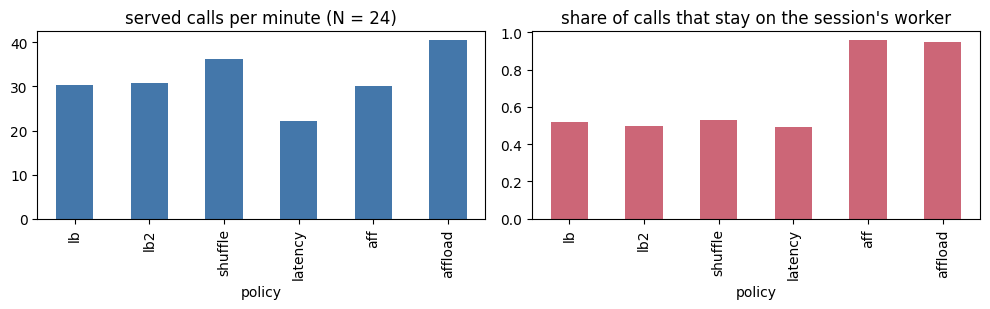

In [8]:
order = ["lb", "lb2", "shuffle", "latency", "aff", "affload"]
rows = []
for v in order:
    s = load("er-n24", v)["summary"]["classes"]["interactive"]
    rows.append({"policy": v, "served/min": load("er-n24", v)["timeline"]["served"].iloc[1:].mean(), "stickiness": s["worker_stickiness"]})
d = pd.DataFrame(rows).set_index("policy")
fig, ax = plt.subplots(1, 2, figsize=(10, 3.2))
d["served/min"].plot.bar(ax=ax[0], color="#4477aa", title="served calls per minute (N = 24)")
d["stickiness"].plot.bar(ax=ax[1], color="#cc6677", title="share of calls that stay on the session's worker")
plt.tight_layout(); plt.show()

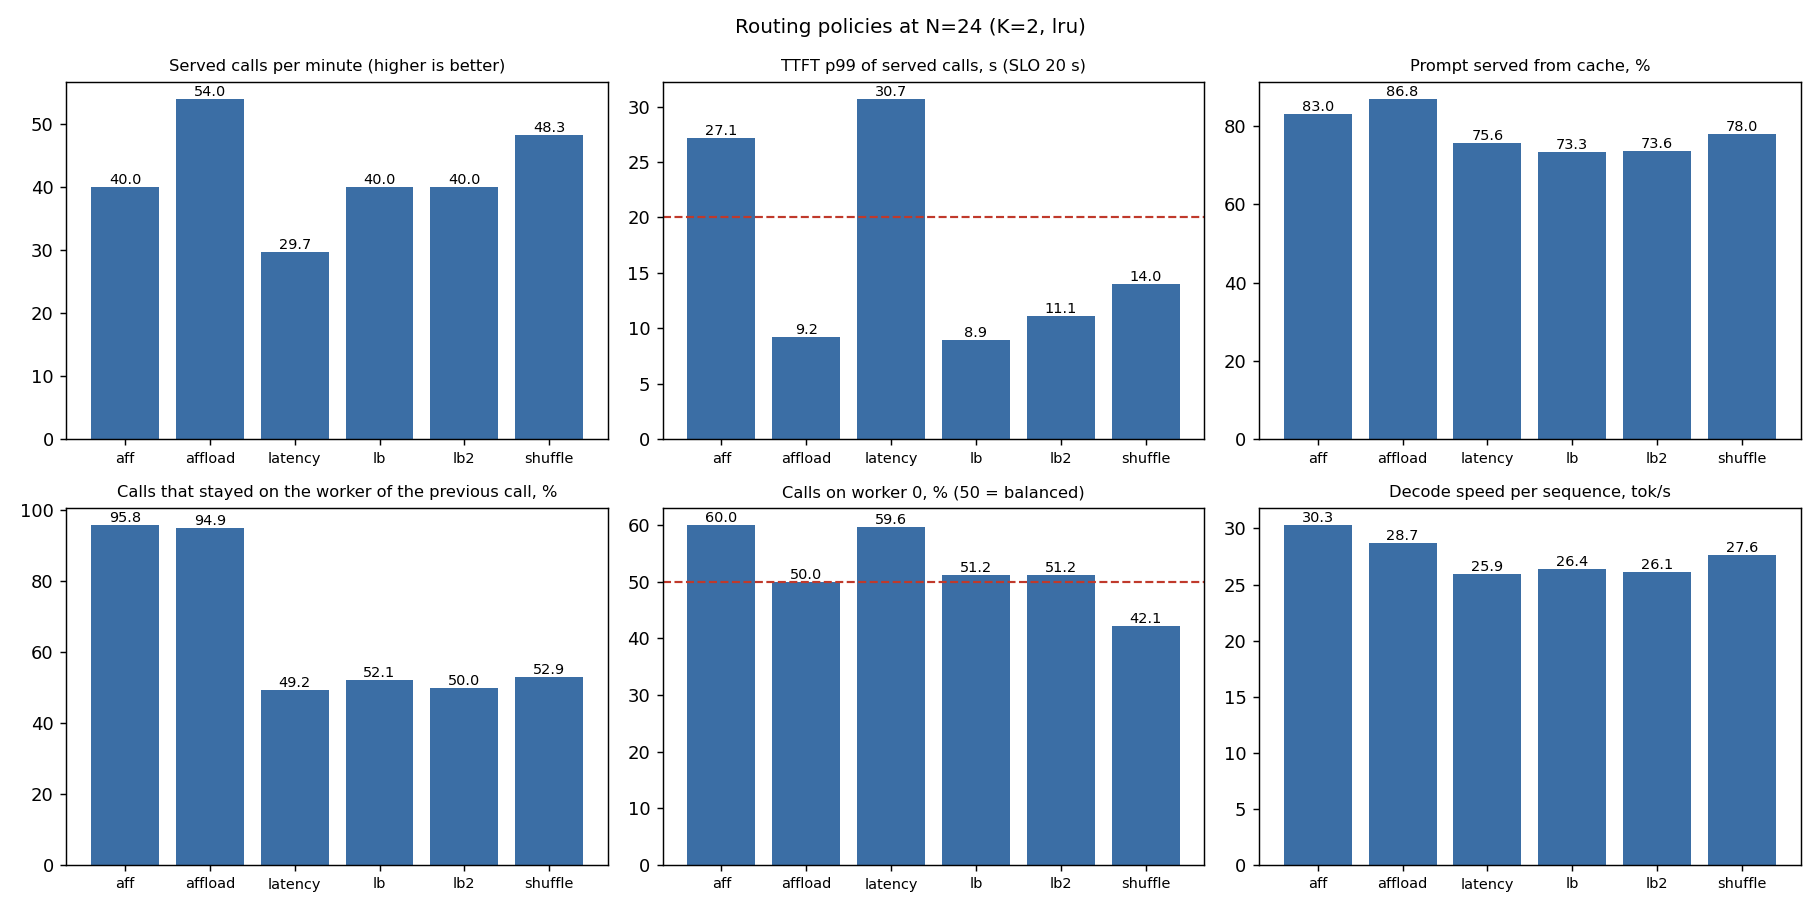

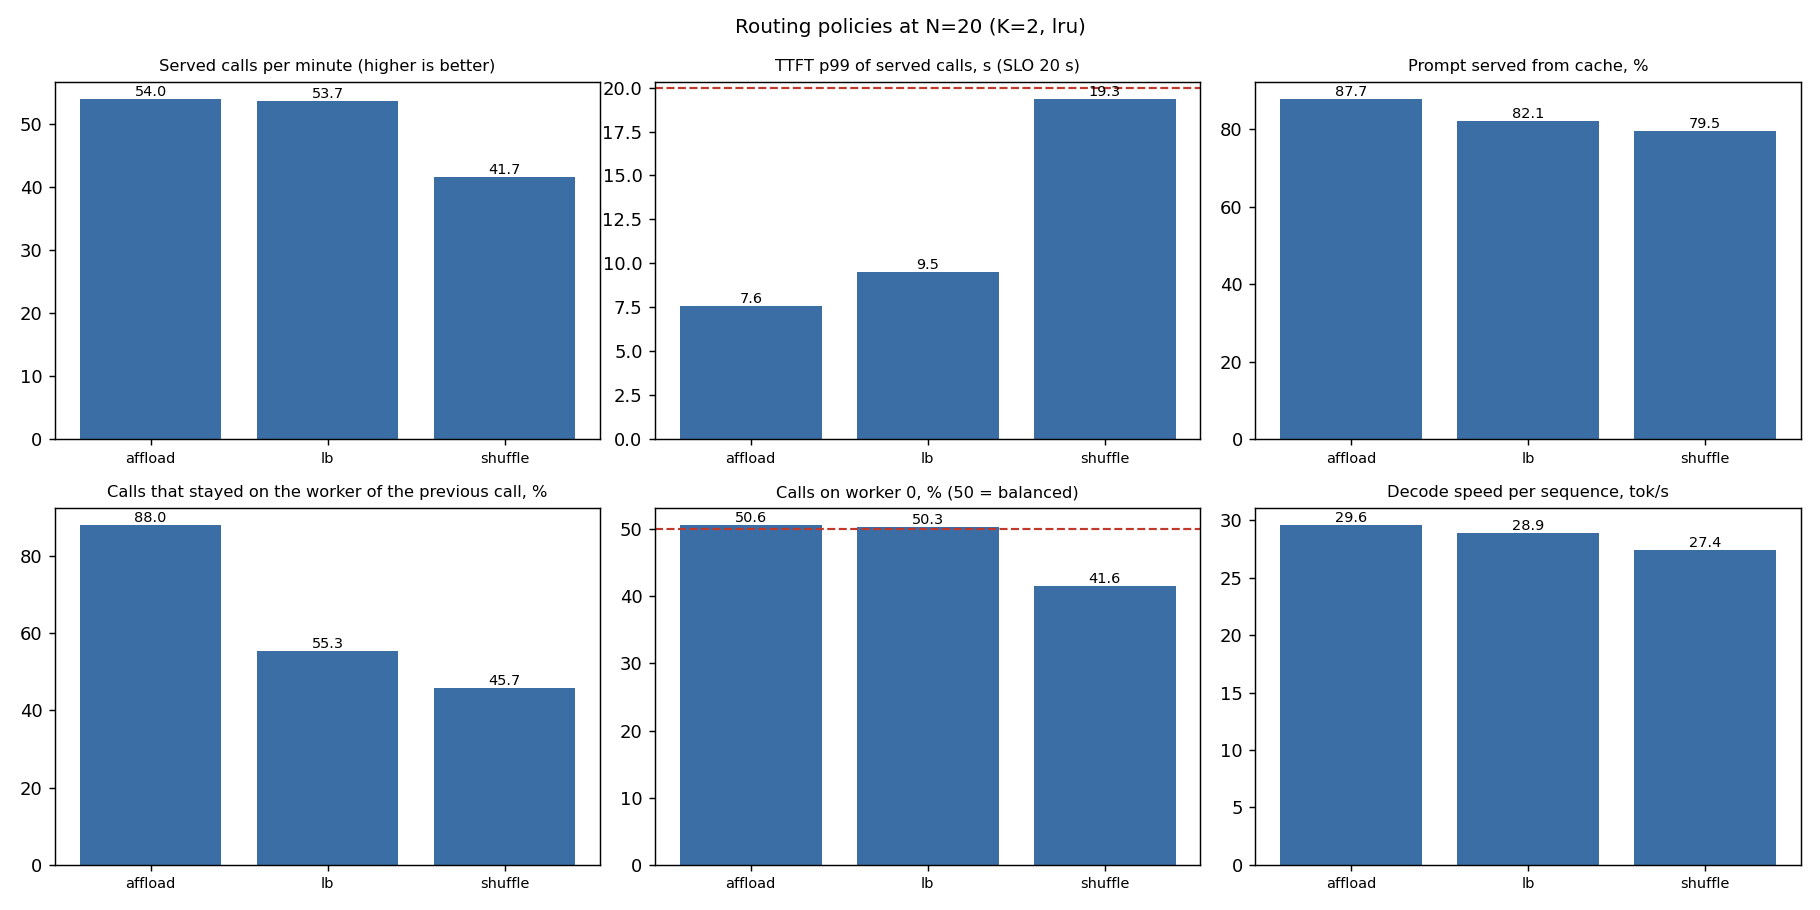

In [9]:
from IPython.display import Image, display
for f in ("plots/routing_n24.png", "plots/routing_n20.png"):
    if (ROOT / f).exists():
        display(Image(filename=str(ROOT / f)))

## 6. KV full after admit: do we shed at the door, or does the engine preempt?

Both, in order. **At the door:** `kv_pressure` refuses a *new* prefix when the fleet KV is at 95 % or more. **After admit:**
the engine retracts the least urgent running request (`--retraction-policy priority`) and re-prefills it later; the gateway
never preempts. In these runs the KV did not fill, so neither fired:

In [10]:
for v in ["lb", "shuffle", "aff", "affload"]:
    p = load("er-n24", v)["prom"]
    kv = series(p, "kv_used_max", "worker")
    shed = sum(s["value"] for s in p["shed_by_reason"] if s["labels"]["reason"] == "kv_pressure")
    ret = sum(series(p, "retracted_max", "worker").values())
    kv_txt = {k: round(x, 2) for k, x in kv.items()}
    print(f"{v:8s} KV used max per worker {kv_txt}  kv_pressure sheds {shed:.0f}  retracted {ret:.0f}")

lb       KV used max per worker {'1': 0.53, '0': 0.52}  kv_pressure sheds 0  retracted 0
shuffle  KV used max per worker {'1': 0.57, '0': 0.58}  kv_pressure sheds 0  retracted 0
aff      KV used max per worker {'1': 0.26, '0': 0.6}  kv_pressure sheds 0  retracted 0
affload  KV used max per worker {'1': 0.58, '0': 0.54}  kv_pressure sheds 0  retracted 0


The binding limit at this load was therefore **not memory** (KV peaked near 55-60 %) but the speed of the work: prefill
interference and cache misses (section 3). With 6 sequences of 64K per worker the KV pool holds 435,199 tokens (6.64 sequences);
the recurrent states of this hybrid model (46 per worker) take the rest of the pool.

**The worst case, on purpose** (`metrics/probes/kv_probe.py`): 12 requests of about 60K tokens at once, then the same with the shed
threshold lowered to 0.70 so that the door acts:

In [11]:
for name in ("kv_probe_default.log", "kv_probe_0.70.log"):
    print("-----", name)
    for line in (ROOT / "metrics/logs" / name).read_text().splitlines():
        if line.startswith(("KV used", "long requests", "new-prefix", "reused-prefix", "extra requests", "orch_requests_shed_total{priority_class=\"interactive\"")):
            print(line[:210])

----- kv_probe_default.log
KV used, worst worker, peak: 83.0 %   engine retractions seen: 0
long requests: [200] statuses; slowest 51.2 s
new-prefix: HTTP 200 in 0.5 s  shed-reason=None 
reused-prefix: HTTP 200 in 6.1 s  shed-reason=None 
----- kv_probe_0.70.log
extra requests sent at 25 s, KV now {'w0': (83.4, 6, 0, 0), 'w1': (83.3, 6, 0, 0)}
KV used, worst worker, peak: 84.6 %   engine retractions seen: 0
long requests: [200] statuses; slowest 63.7 s
new-prefix: HTTP 503 in 0.1 s  shed-reason=kv_pressure {"error":{"message":"Fleet KV usage is 83% and the prefix is new. Try again later.","type":"internal
reused-prefix: HTTP 200 in 35.8 s  shed-reason=None 
orch_requests_shed_total{priority_class="interactive",reason="kv_pressure",status_code="503"} 1.0


The KV peaks at 83-85 % with **zero retractions**: 6 running sequences x 64K cannot take more than 88 % of the pool, so after admission
the engine never has to preempt, and the 95 % threshold cannot be reached by running sequences. With the threshold lowered, a request
with a **new prefix is refused in 0.1 s with a 503 `kv_pressure`** and one that reuses a seen prefix is admitted: shedding at the door
protects the KV when it is full; the engine preempts only if it ever overcommits (it did not).

## 7. Client gone (aborted): who frees the KV, and how?

LiteLLM runs with `cancel_on_disconnect: true`: when the client leaves, LiteLLM closes the upstream connection and **SGLang
aborts the request and frees its KV blocks**. The gateway's place (one of the 14 of LiteLLM's cap) is released when the request ends, because
the cap is a semaphore held for the life of the request. Verified with a probe that watches the engine (`metrics/logs/conn.log`, `conn4.log`):

In [12]:
for name in ("conn.log", "conn4.log"):
    text = (ROOT / "metrics/logs" / name).read_text()
    for line in text.splitlines():
        if line.startswith("VERDICT") or "VERDICT" in line or line.startswith("== s"):
            print(f"{name}: {line.strip()}")

conn.log: == s1: streaming client leaves at 3 s while running (max_tokens=800)
conn.log: VERDICT: upstream closed (generation stopped early)
conn.log: == s2: non-streaming client leaves at 3 s while running (max_tokens=800)
conn.log: VERDICT: upstream closed (generation stopped early)
conn.log: == s3: client leaves while its request is QUEUED in SGLang
conn.log: == s4: LiteLLM cuts a QUEUED request at TTFT_CUT_S (expected tokens if the cut frees the place: 14 x 600 = 8400)
conn.log: VERDICT: the cut removed the request from SGLang
conn4.log: == s4: LiteLLM cuts a QUEUED request at TTFT_CUT_S. Look in the SGLang log for a prefill of ~1,200 tokens: if it appears after the cut, SGLang served the request to nobody


Results of that probe: a streaming client that leaves while its request runs (s1) and a non-streaming one (s2) both end with
the upstream closed and generation stopped early; and when LiteLLM itself cuts a queued request at its `stream_timeout` (s4) the request is removed from SGLang (verified live: 408 at 4.2 s). That first-token cut
was later removed because the same timeout fires in the middle of a stream while a tool call's arguments are generated (decisions 59, 61). A client that leaves while its request is **still queued** in SGLang (s3) was not measured separately (its log has no verdict line), but it is covered by the same configuration: `cancel_on_disconnect: true` makes LiteLLM close the upstream connection whatever state the request is in, and s4 showed that when LiteLLM closes the upstream of a queued request SGLang removes it from its queue (the cut removed the request from SGLang). So the answer is the configuration, with that indirect evidence, not a dedicated measurement.

## 8. After a worker returns: slam it at 100 % or ramp?

"Ready" (model loaded, port open) is not "warm". `script/warm_workers.py` (stage 5b of `launch_cluster.sh`) measures the
first-token time of a unique 4K-token prompt **cold**, warms the worker with prompt shapes the agent sends, and measures
again; LiteLLM is applied only after both workers pass. The SLO is quoted from the **warm** number.

In [13]:
for name, what in (("warm_workers.json", "workers up for 140 min (already warm)"), ("warm_after_restart.json", "worker 1 just restarted")):
    f = ROOT / "metrics/probes" / name
    if f.exists():
        print(f"{name}: {what}")
        print(pd.DataFrame(json.load(open(f))))
    else:
        print(name, "not present")

warm_workers.json: workers up for 140 min (already warm)
    port  cold_ttft_s      round_mean_ttft_s  warm_ttft_s  warm
0  30000        0.297  [0.267, 0.262, 0.264]        0.292  True
1  30001        0.303   [0.29, 0.276, 0.264]        0.296  True
warm_after_restart.json: worker 1 just restarted
    port  cold_ttft_s     round_mean_ttft_s  warm_ttft_s  warm
0  30001        1.763  [1.06, 0.328, 0.287]        0.316  True


**At run time** a worker that comes back is not slammed to 100 %: `place.py` gives it 25 % of its weight and raises it to 100 %
over 60 s, pausing while the fleet TTFT p99 is above 10 s, and never picks it while its metrics do not answer. The probe restarts
worker 1 under a constant load of new sessions (`metrics/probes/ramp_probe.py`; columns: requests, served by worker 0 and 1, errors,
share of worker 1, and the gauges `orch_worker_available` and `orch_worker_ramp_factor` of worker 1):

In [14]:
print((ROOT / "metrics/logs/ramp_probe.log").read_text())

[40s] restarting worker 1
window  requests  w0  w1  errors   share_w1   gauges (available_w1, ramp_factor_w1)
    0s        14   7   7       0   0.5   (1.0, 1.0)
   15s        16   8   8       0   0.5   (1.0, 1.0)
   30s        12   6   3       3   0.33   (1.0, 1.0)
   45s         6   6   0       0   0.0   (0.0, 1.0)
   60s         9   9   0       0   0.0   (0.0, 1.0)
   75s         6   6   0       0   0.0   (0.0, 1.0)
   90s         9   9   0       0   0.0   (0.0, 1.0)
  105s        12  12   0       0   0.0   (0.0, 1.0)
  120s        12  12   0       0   0.0   (0.0, 1.0)
  135s        12  12   0       0   0.0   (0.0, 1.0)
  150s        18  18   0       0   0.0   (0.0, 1.0)
  165s        12  12   0       0   0.0   (0.0, 1.0)
  180s        12  12   0       0   0.0   (0.0, 1.0)
  195s        12  12   0       0   0.0   (0.0, 1.0)
  210s        12  12   0       0   0.0   (0.0, 1.0)
  225s        12  12   0       0   0.0   (0.0, 1.0)
  240s        12  12   0       0   0.0   (0.0, 1.0)
  255

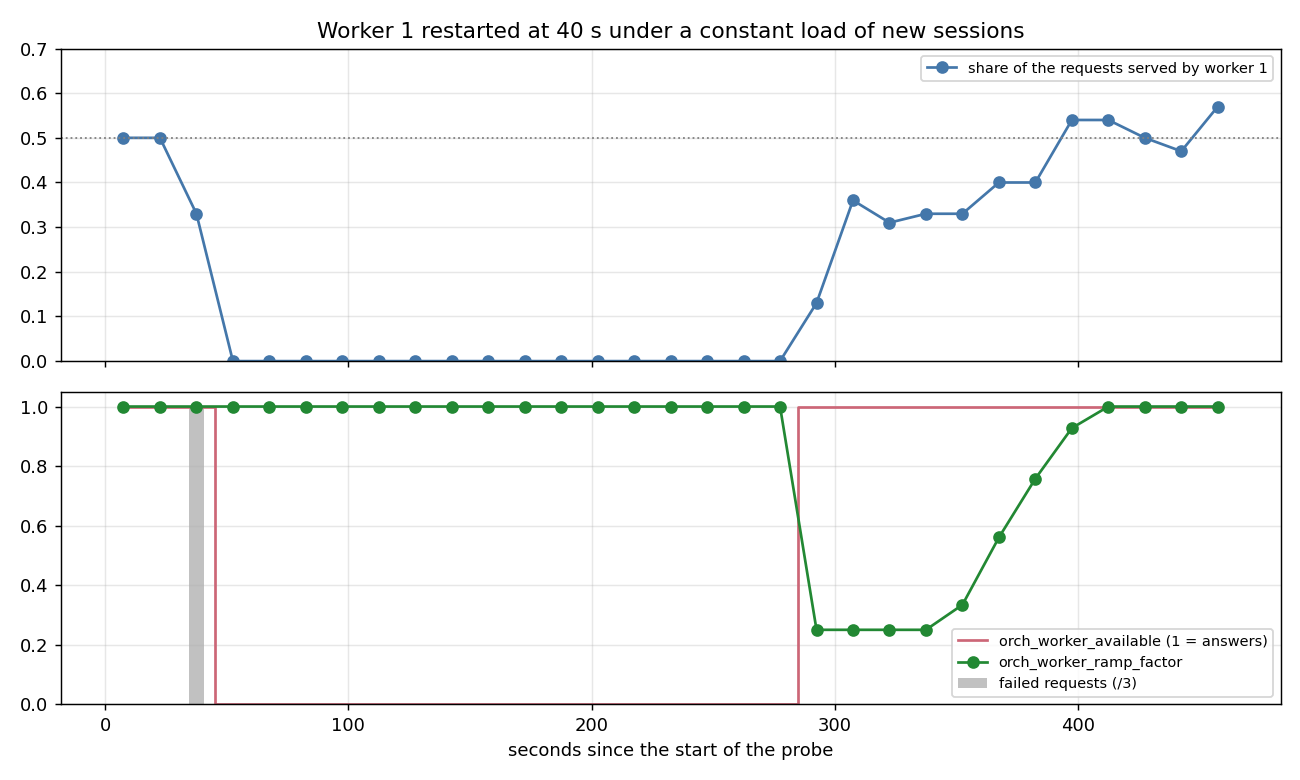

In [15]:
from IPython.display import Image, display
if (ROOT / "plots/final_ramp.png").exists():
    display(Image(filename=str(ROOT / "plots/final_ramp.png")))

Reading: 3 requests failed when the pod died (the ones in flight); then nothing went to worker 1 for four minutes and there were no more
errors; when it answered again its share started at 0.13 and climbed to 0.54 over about 125 s, the ramp factor staying at 0.25 for ~45 s
because the cold worker pushed the fleet p99 above the hold.

## 9. Hop: when does KV move, and is the destination warm?

`src == dst`: the prefix is already on the device, nothing moves (`orch_hops_local_total`). `src != dst`: the other worker
reads the prefix that this one published to Mooncake instead of recomputing it. Probe 5 (direct to the workers, 47K-token prefix):

In [16]:
print(pd.DataFrame([
  {"case": "cold prefill, worker 0", "TTFT s": 4.48, "cached tokens": 0},
  {"case": "same prefix, same worker (src == dst)", "TTFT s": 0.94, "cached tokens": 46976},
  {"case": "same prefix on the OTHER worker (src != dst, via Mooncake L3)", "TTFT s": 2.28, "cached tokens": 46912},
]))
tot = sum(s["value"] for s in prom["placement_sessions"])
print({s["labels"]["result"]: round(s["value"]/tot, 3) for s in prom["placement_sessions"]}, "<- affload: new / kept / moved sessions")

                                                case  TTFT s  cached tokens
0                             cold prefill, worker 0    4.48              0
1              same prefix, same worker (src == dst)    0.94          46976
2  same prefix on the OTHER worker (src != dst, v...    2.28          46912
{'new': 0.167, 'kept': 0.702, 'moved': 0.131} <- affload: new / kept / moved sessions


A hop costs about 1.3 s more than a local hit and saves about 2.2 s against recomputing. The gateway records every hop
(`orch_hops_total`, `orch_hop_tokens_total`, `orch_hop_cached_tokens_total`) and prints a `HOP` line; the dictionary below is from
a 200 s run with `lb` at N = 16 (`metrics/evidence/after-ev-n16/hop_dictionary.jsonl`):

In [17]:
hops = pd.read_json(ROOT / "metrics/evidence/after-ev-n16/hop_dictionary.jsonl", lines=True)
print(len(hops), "hops;", f"{hops.cached_tokens.sum() / hops.tokens.sum():.0%}", "of their", int(hops.tokens.sum()), "prompt tokens were read from cache on the destination")
print(hops.groupby(["src", "dst"]).agg(n=("tokens", "size"), tokens=("tokens", "sum"), cached=("cached_tokens", "sum")))
hops.head(5)

40 hops; 82% of their 1815245 prompt tokens were read from cache on the destination
          n  tokens  cached
src dst                    
w0  w1   20  925559  783354
w1  w0   20  889686  704840


,backend,cached_tokens,dst,prefix,session,src,tokens
0,mooncake,49516,w1,17668a90f4ca,9e982250dce8,w0,51343
1,mooncake,46865,w1,17668a90f4ca,aa96dd87d9ce,w0,49463
2,mooncake,44672,w1,17668a90f4ca,d5aba596f2eb,w0,46829
3,mooncake,53760,w1,17668a90f4ca,ef2e3a95a67d,w0,55836
4,mooncake,40918,w0,17668a90f4ca,6d83f26961d3,w1,43475


Eviction and 429/503 counts of the same run (`metrics/evidence/after-ev-n16/`):

In [18]:
ev = ROOT / "metrics/evidence/after-ev-n16"
for name in ("evict_count.txt", "status_429_503.txt"):
    print(f"--- {name}"); print("\n".join(l[:170] for l in (ev / name).read_text().splitlines()))

--- evict_count.txt
sglang:hicache_dropped_tokens_total{cache_type="UnifiedRadixCache",dp_rank="0",pool="kv",pp_rank="0",reason="host_pressure",tp_rank="0"} 0.0
sglang:hicache_dropped_tokens_total{cache_type="UnifiedRadixCache",dp_rank="0",pool="kv",pp_rank="0",reason="write_through_unbacked_eviction",tp_rank="0"} 0.0
sglang:evicted_tokens_total{cache_type="UnifiedRadixCache",dp_rank="0",pp_rank="0",tp_rank="0"} 1.2546206e+07
sglang:hicache_dropped_tokens_total{cache_type="UnifiedRadixCache",dp_rank="0",pool="kv",pp_rank="0",reason="host_pressure",tp_rank="0"} 0.0
sglang:hicache_dropped_tokens_total{cache_type="UnifiedRadixCache",dp_rank="0",pool="kv",pp_rank="0",reason="write_through_unbacked_eviction",tp_rank="0"} 0.0
sglang:evicted_tokens_total{cache_type="UnifiedRadixCache",dp_rank="0",pp_rank="0",tp_rank="0"} 554543.0
--- status_429_503.txt
# orch_requests_shed_total (status_code 429 = tenant limits, 503 = capacity); LiteLLM's own proxy status counters below
orch_requests_shed_tot

Tenant limits (429, never an overflow) were checked with `metrics/probes/tenant_probe.py`:

In [19]:
print((ROOT / "metrics/logs/tenant_probe.log").read_text())

tenant  call  status  seconds
acme       0     200  3.98
acme       1     200  3.96
acme       2     200  3.94
acme       3     429  0.03
acme       4     429  0.02
acme       5     429  0.02
beta       0     200  3.94
acme statuses: [200, 200, 200, 429, 429, 429] | beta statuses: [200]
--- LiteLLM counters per key alias
  tenant-acme HTTP 429: 3.0
  tenant-acme HTTP 200: 1.0
  tenant-acme HTTP 200: 2.0
  tenant-beta HTTP 200: 1.0



## 10. The finished system under load: the final tests

Synthetic sessions (`script/loadgen.py`) with the final configuration (K = 2, `affload`; the runs F1-F5 had a first-token cut of 20 s that fired once and was later removed). The knee, the replicate
against LiteLLM's `least-busy` (same conversations), the 20 % batch run, regime B (120 s idle) and a 15-minute soak:

In [20]:
import json
rows = []
for tag, n in [("fin-knee", 16), ("fin-knee", 20), ("fin-knee", 24), ("fin-rep-affload", 20), ("fin-rep-lb", 20),
               ("fin-batch", 20), ("fin-regimeB", 48), ("fin-soak", 16)]:
    v = json.load(open(RUNS / tag / f"N{n}" / "summary.json"))["classes"]["interactive"]
    rows.append({"run": tag, "N": n, "served/min": v["served_per_min"], "TTFT p50": round(v["ttft_p50"], 1), "TTFT p99": round(v["ttft_p99"], 1),
                 "refused %": round(100 * v["shed_rate"], 1), "abandoned": f"{v['calls_abandoned']}/{v['calls']}",
                 "cached %": round(100 * v["cached_tokens_reported"] / v["prompt_tokens"]), "stickiness": v["worker_stickiness"]})
pd.DataFrame(rows)

,run,N,served/min,TTFT p50,TTFT p99,refused %,abandoned,cached %,stickiness
0,fin-knee,16,47.00,1.1,9.3,3.7,1/236,88,0.918
1,fin-knee,20,56.80,1.7,7.7,38.4,23/307,88,0.924
2,fin-knee,24,46.40,2.3,13.7,70.1,124/356,82,0.803
3,fin-rep-affload,20,50.40,1.9,10.3,48.8,33/285,88,0.853
4,fin-rep-lb,20,43.60,2.7,11.5,53.0,51/269,74,0.540
5,fin-batch,20,43.20,0.9,7.4,1.4,0/216,91,0.965
6,fin-regimeB,48,38.40,4.5,14.9,84.7,310/502,66,0.884
7,fin-soak,16,48.57,1.0,7.1,1.7,1/681,90,0.935


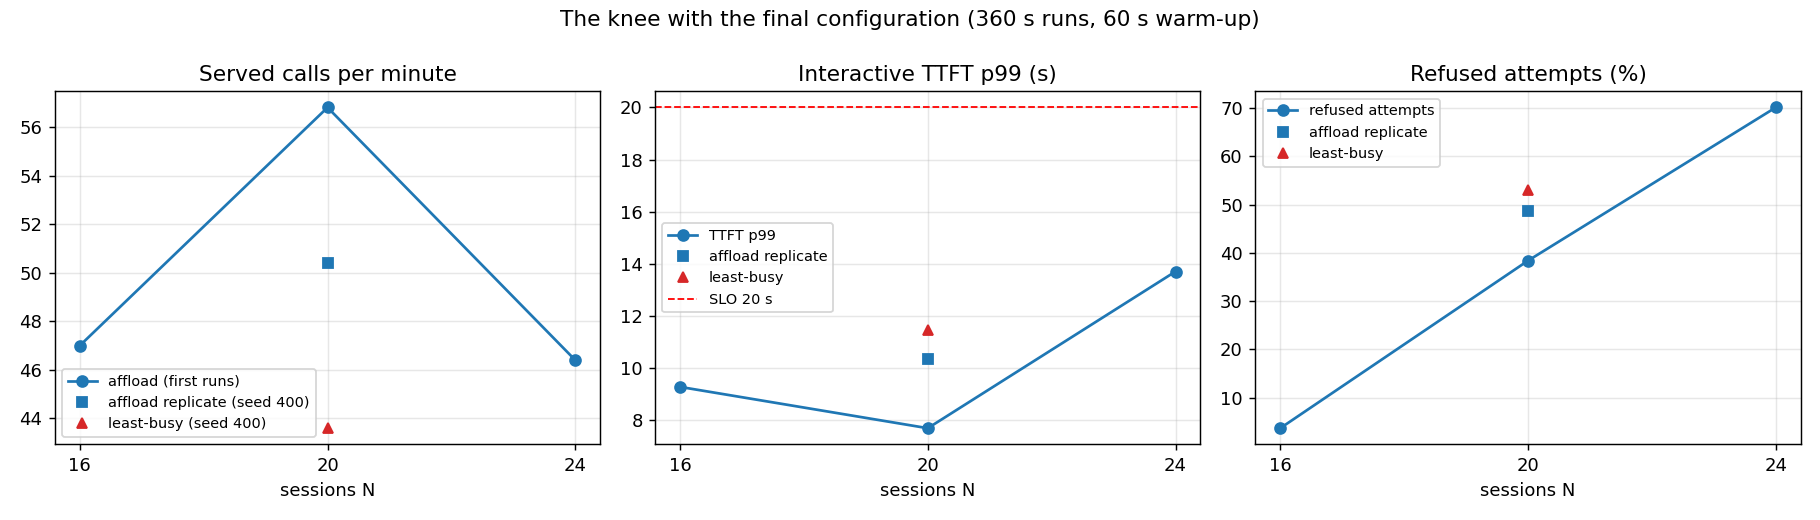

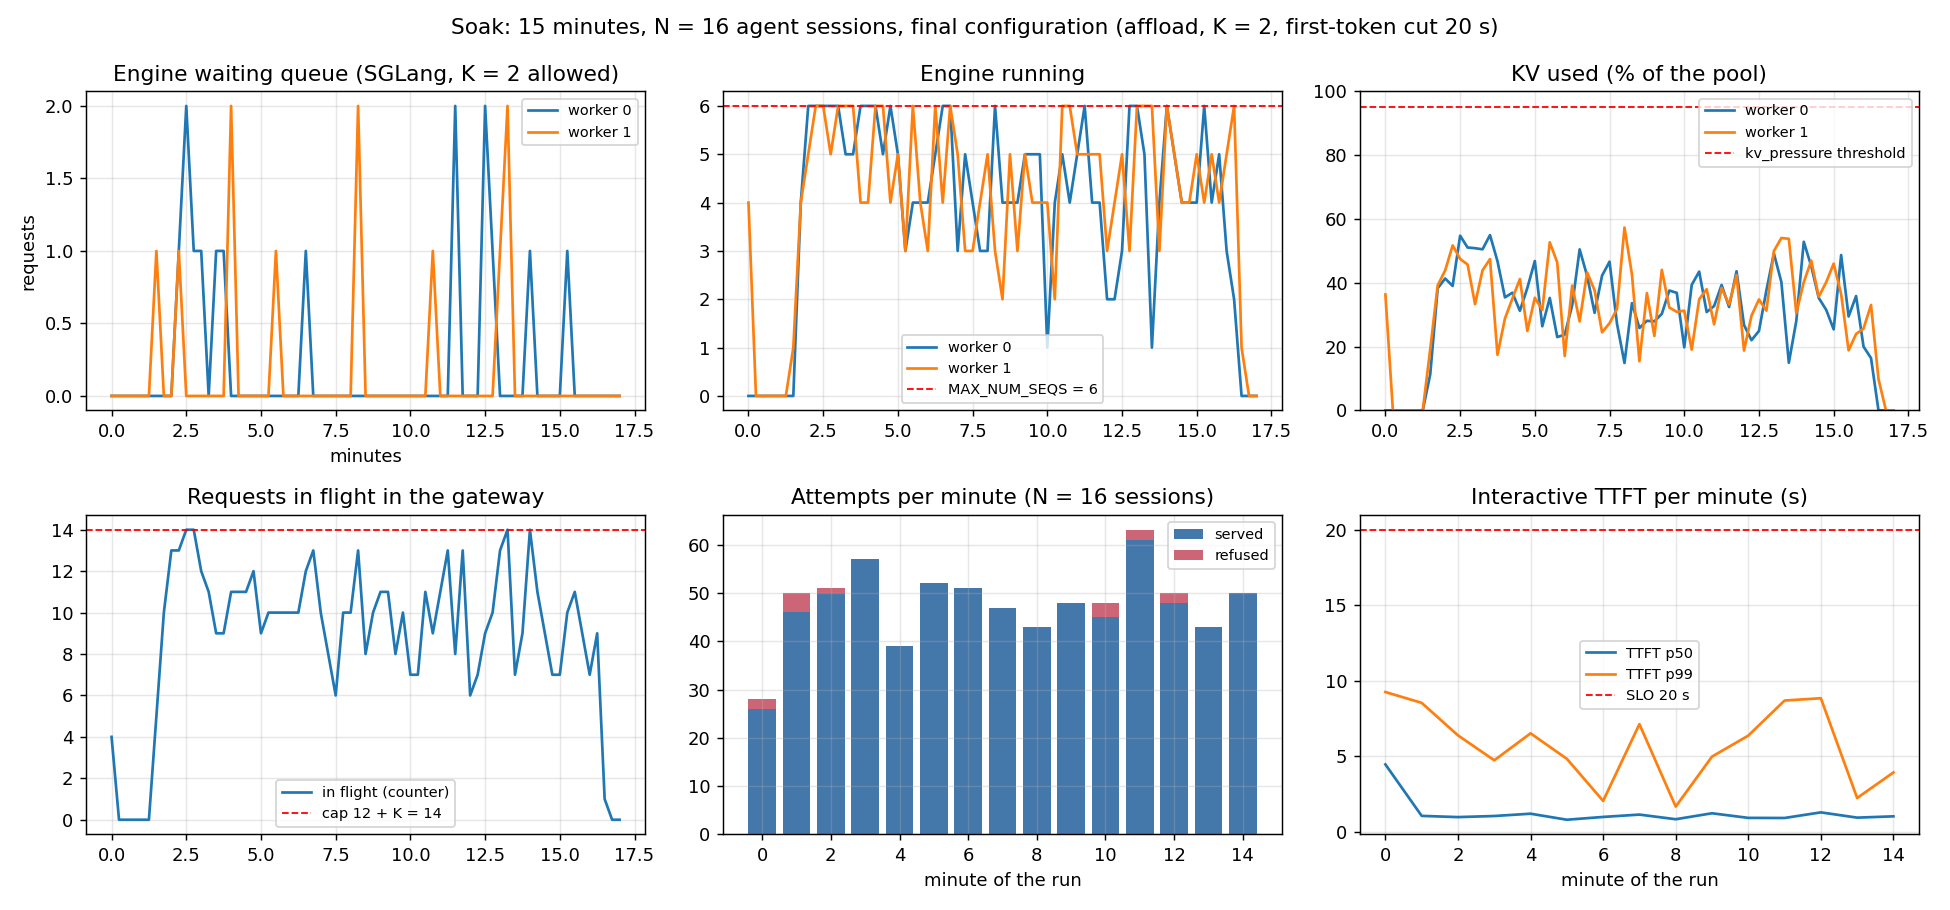

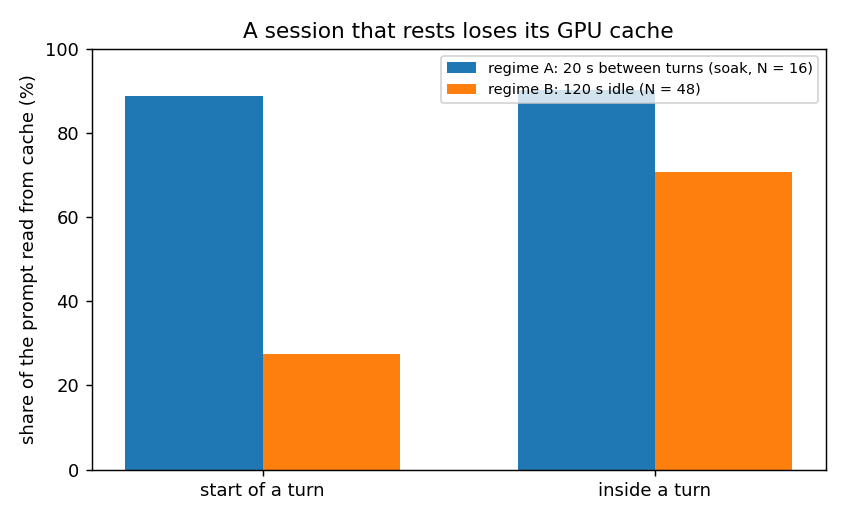

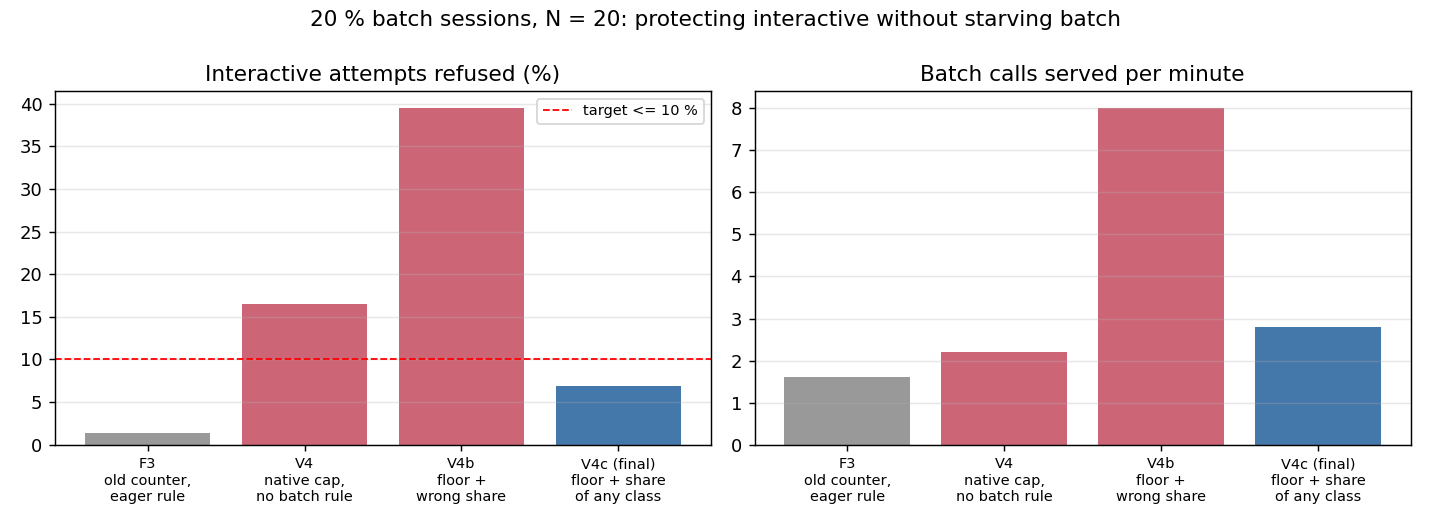

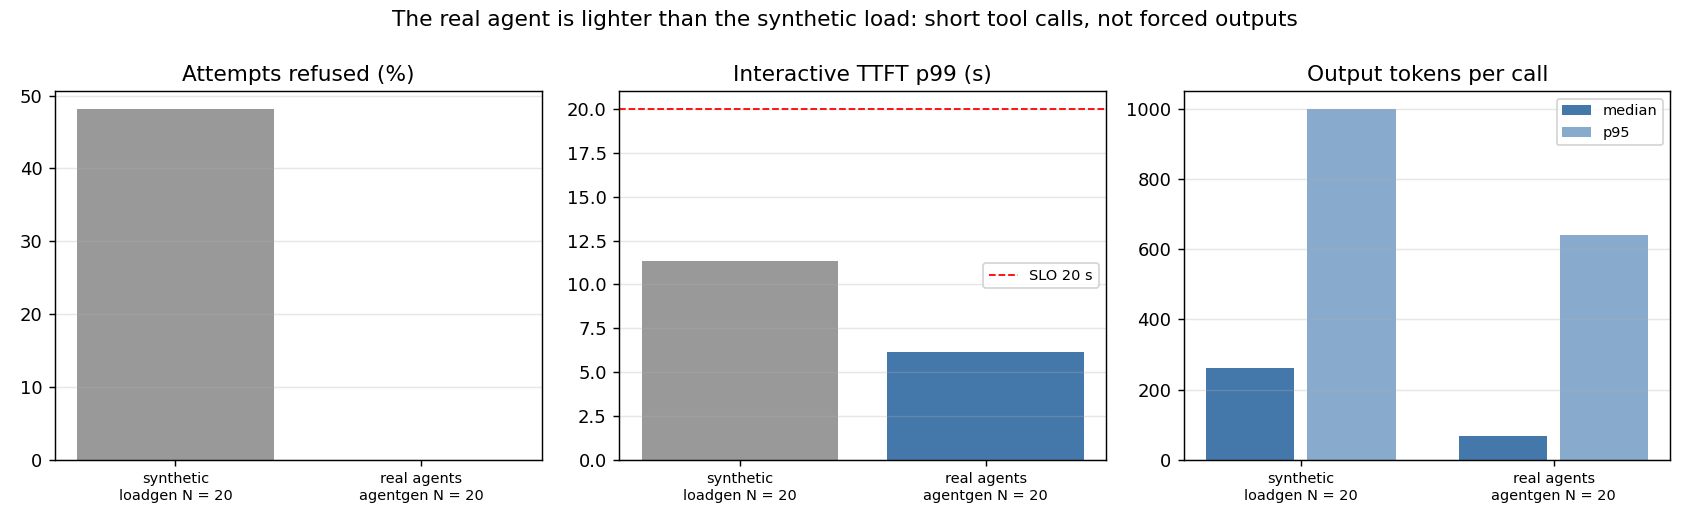

In [21]:
from IPython.display import Image, display
for f in ("plots/final_knee.png", "plots/final_soak.png", "plots/final_cache_regimes.png", "plots/final_batch.png", "plots/final_agents.png"):
    if (ROOT / f).exists():
        display(Image(filename=str(ROOT / f)))

Reading: refusals stay below 5 % up to N = 16; above it the cap refuses 38-70 % of the attempts but the served ones keep their TTFT p99
between 7 and 14 s against the 20 s SLO. Paired at N = 20, `affload` beats `least-busy` on every number. A session that rests 120 s
reads only 27 % of the first prompt of a turn from cache. The soak is flat: queue <= 2, KV <= 57 %, nothing leaked.

## 11. Real agents: tool-using sessions (`script/agentgen.py`)

`loadgen.py` is synthetic (random text, no tools, forced output lengths). `agentgen.py` runs real sessions: the model reads files of this
repository through three tools (`read_file`, `list_dir`, `grep`), decides when it has enough and answers; the history is what happened.

In [22]:
import glob
paths = sorted(glob.glob(str(RUNS / "fin2-agents" / "N*" / "summary.json")))
if not paths:
    print("no agentic runs saved yet (metrics/runs/fin2-agents)")
for path in paths:
    s = json.load(open(path))
    v = s["classes"]["interactive"]
    print(path.split("/")[-2], "| served/min", v["served_per_min"], "| TTFT p50/p99", round(v["ttft_p50"], 1), round(v["ttft_p99"], 1),
          "| refused %", round(100 * v["shed_rate"], 1), "| cached %", round(100 * v["cached_tokens_reported"] / v["prompt_tokens"]))
    print("   ", json.dumps(s["agent"]))

N12 | served/min 38.0 | TTFT p50/p99 0.8 3.5 | refused % 0.0 | cached % 88
    {"turns_finished": 93, "turns_cut_or_lost": 13, "steps_per_finished_turn_p50": 2, "steps_per_finished_turn_max": 12, "tool_calls_by_name": {"read_file": 109, "grep": 43, "list_dir": 52}, "malformed_tool_calls": 1, "tool_result_tokens_p50": 649, "tool_result_tokens_p95": 5013, "compactions": 0}
N20 | served/min 55.8 | TTFT p50/p99 1.0 6.1 | refused % 0.0 | cached % 79
    {"turns_finished": 153, "turns_cut_or_lost": 4, "steps_per_finished_turn_p50": 2, "steps_per_finished_turn_max": 12, "tool_calls_by_name": {"read_file": 173, "list_dir": 25, "grep": 86}, "malformed_tool_calls": 0, "tool_result_tokens_p50": 1162, "tool_result_tokens_p95": 5013, "compactions": 1}


## 12. Live scrape (only if a Prometheus is reachable)

In [23]:
queries = {
  "requests in flight (cap 14)": "litellm_litellm_admission_admitted_requests",
  "engine waiting per worker": "sglang:num_queue_reqs{priority=\"\"}",
  "engine running per worker": "sglang:num_running_reqs{priority=\"\"}",
  "shed by reason": "sum by (reason, status_code) (litellm_orch_requests_shed_total)",
  "rejected by the cap": "sum by (reason) (litellm_litellm_admission_rejected_requests_total)",
  "orch_replica_queue_depth (per replica)": "litellm_orch_replica_queue_depth",
  "orch_replica_running_requests (per replica)": "litellm_orch_replica_running_requests",
  "hops": "sum by (src, dst) (litellm_orch_hops_total)",
  "overflow decisions": "sum by (decision, status) (litellm_orch_overflow_decisions_total)",
  "requests by key": "sum by (api_key_alias, status_code) (litellm_litellm_proxy_total_requests_metric_total)",
  "evicted tokens": "sglang:evicted_tokens_total",
}
for name, q in queries.items():
    res = live(q)
    if res is None:
        print(f"{name:28s} Prometheus not reachable (open the tunnel to :9090 to scrape live)"); continue
    print(f"{name:28s}", [(x["metric"].get("worker") or x["metric"].get("replica") or x["metric"].get("reason") or x["metric"].get("decision") or x["metric"].get("src") or x["metric"].get("api_key_alias") or "", x["value"][1]) for x in res][:8])

requests in flight (cap 14)  [('', '0')]


engine waiting per worker    [('1', '0'), ('0', '0')]


engine running per worker    [('1', '0'), ('0', '0')]


shed by reason               [('timeout_queue', '0'), ('kv_pressure', '0'), ('batch_pressure', '0'), ('batch_share', '0'), ('no_healthy_worker', '0')]


rejected by the cap          [('queue_full', '2')]


...

orch_replica_running_requests (per replica) [('sglang-worker-0', '0'), ('sglang-worker-1', '0')]


hops                         []


overflow decisions           []


requests by key              [('None', '1'), ('pi-demo', '3'), ('None', '28'), ('loadgen', '30')]


evicted tokens               [('1', '7983')]
